# ĐỒ ÁN THỰC HÀNH #2

## Giai đoạn 2: EDA

## Môn học: Phân tích dữ liệu ứng dụng - CSC12110

Các thành viên và bảng đánh giá:

| STT | MSSV     | Họ tên           | Công việc đã thực hiện trong giai đoạn 2 | Tỉ lệ công việc (trên tổng số 100%) | Đánh giá (thang 100%) | Ghi chú |
| --- | ----     | ---------------- | ---------------------- | --------------- | --------------------- | ------- |
| 1   | 22127012 | Nguyễn Hà Anh    | Thực hiện EDA phần 2.1 | 25% | 100% |  |
| 2   | 22127205 | Bùi Lê Khôi      | Thực hiện EDA phần 2.4 | 25% | 100% | Leader |
| 3   | 22127260 | Bùi Công Mậu     | Thực hiện EDA phần 2.5 | 25% | 100% |  |
| 4   | 22127400 | Thái Hữu Thọ     | Thực hiện EDA phần 2.2, 2.3 | 25% | 100% |  |


---

Link sản phẩm:

- Drive: [DA_05_S1_2526](https://drive.google.com/drive/u/0/folders/1TPJKcKhVyfVeW6RG4pF22pNRB-k1RA9r)
  - Giai đoạn 1 - Data Cleaning & Data Preprocessing: [DA_05_GD1_Preprocessing](https://colab.research.google.com/drive/12gd8Hqaj5c117MPsPFZiHgXDFbH3MjDn)
  - Giai đoạn 2 - EDA: [DA_05_GD2_EDA](https://colab.research.google.com/drive/1nnAVOIJJaglbqq1lOBo9OiKlEMXFFqnO)
  - Giai đoạn 3 - Hypothesis Testing: [DA_05_GD3_Hypothesis_Testing](https://colab.research.google.com/drive/1gVtnBd4bN6eDq8xDgmxVu3IEwPYaTBsa)
  - Giai đoạn 4 - DA_05_GD4_Model_Evaluation + Bonus Tasks: [DA_05_GD4_Model_Evaluation+Bonus](https://colab.research.google.com/drive/1DE0dN8WIMKHM_72EjdzM_iXx8nAXOCLM)

- Video Demo: [Final_DA_05](https://drive.google.com/file/d/1cvEYJuuxS5Zg5s358HRbRD8DQqvk3WBg/view)

---


## Mô tả đồ án

- Mục tiêu: **Dự đoán khả năng một người có mắc bệnh tim hay không**.

    - Biến mục tiêu: ```target``` (1 = bệnh, 0 = không bệnh).

- Dataset: [Heart Disease UCI Dataset](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data)

---

### Import các libs và dependencies

In [ ]:
import re
import os
import math

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl as pxl
import seaborn as sns
import statsmodels.api as sm
import datetime as dt

from datetime import timedelta
from scipy import stats
from math import sqrt

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, pairwise_distances, silhouette_score, precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from google.colab import drive
import warnings
warnings.filterwarnings("ignore")

# Ensure plots appear in the notebook
%matplotlib inline

# Print last updated timestamp
import time
print(f"Last updated: {time.asctime()}")

Last updated: Wed Dec 31 16:49:55 2025


In [ ]:
# authorization
drive.mount('/content/drive')

# Check if the directory exists and list files
folder_path = '/content/drive/MyDrive/DA_05_S1_2526'

if os.path.exists(folder_path):
    print("Folder found. Files inside:")
    print(os.listdir(folder_path))
else:
    print(f"Folder not found at: {folder_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder found. Files inside:
['PTDLUD_HK1_2526_DATH_nopass.pdf', 'Ôn thi cuối kì.gdoc', 'heart_disease_uci.csv', 'DA_05_GD3_Hypothesis_Testing.ipynb', 'DA_05_GD4_Model_Evaluation+Bonus.ipynb', 'DA_05_GD1_Preprocessing.ipynb', 'DA_05_GD2_EDA.ipynb', 'heart_disease_uci_preprocessed.csv']


---
---

#  Giai đoạn 2: EDA

## 2.0. Đọc dữ liệu

In [ ]:
# Read preprocessed csv file
df = pd.read_csv('/content/drive/MyDrive/DA_05_S1_2526/heart_disease_uci_preprocessed.csv')
# Check the data
df

,id,age,sex,location,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,1,63,1,Cleveland,1,145.0,233.0,1,2,150.0,0,2.3,3,0,7,0
1,2,67,1,Cleveland,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,2
2,3,67,1,Cleveland,4,120.0,229.0,0,2,129.0,1,2.6,2,2,6,1
3,4,37,1,Cleveland,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0
4,5,41,0,Cleveland,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,0,VA Long Beach,4,127.0,333.0,1,1,154.0,0,0.0,2,0,3,1
916,917,62,1,VA Long Beach,1,132.0,139.0,0,1,138.0,0,0.5,2,0,3,0
917,918,55,1,VA Long Beach,4,122.0,223.0,1,1,100.0,0,0.0,2,0,7,2
918,919,58,1,VA Long Beach,4,132.0,385.0,1,2,138.0,0,0.5,2,0,3,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    int64  
 3   location  920 non-null    object 
 4   cp        920 non-null    int64  
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       920 non-null    int64  
 8   restecg   920 non-null    int64  
 9   thalach   920 non-null    float64
 10  exang     920 non-null    int64  
 11  oldpeak   920 non-null    float64
 12  slope     920 non-null    int64  
 13  ca        920 non-null    int64  
 14  thal      920 non-null    int64  
 15  num       920 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 115.1+ KB


### Mô tả dữ liệu của ```heart_disease_uci_preprocessed.csv```

- Dữ liệu có 920 dòng và 16 cột.

- Các **đặc trưng đầu vào** trong dataset trên gồm:
    - ```id```: Mã số duy nhất cho mỗi bệnh nhân (```int```).
    - ```age```: Tuổi của bệnh nhân (```int```).
    - ```sex```: Giới tính (Male - Nam = ```1``` /Female - Nữ = ```0```).
    - ```location```: Nơi nghiên cứu. Giá trị nằm trong tập {Cleveland, Hungary, Switzerland, VA Long Beach}
    - ```cp```: Loại đau thắt ngực. Giá trị gồm:
        - ```typical angina```: đau thắt ngực điển hình = ```1```
        - ```atypical angina```: đau thắt ngực không điển hình = ```2```
        - ```non-anginal```: không đau thắt ngực = ```3```
        - ```asymptomatic```: không triệu chứng = ```4```
    - ```trestbps```: Huyết áp lúc nghỉ (tính bằng mmHg khi nhập viện) (```float```)
    - ```chol```: Nồng độ cholesterol huyết thanh tính bằng mg/dl (```float```).
    - ```fbs```: Trả về ```1``` nếu đường huyết lúc đói > 120 mg/dl, ngược lại trả về ```0```.
    - ```restecg```: Kết quả điện tâm đồ lúc nghỉ: Giá trị gồm:
        - ```normal```: bình thường = ```0```
        - ```stt abnormality```: bất thường ST-T = ```1```
        - ```lv hypertrophy```: phì đại thất trái = ```2```
    - ```thalach```: nhịp tim tối đa đạt được (```float```)
    - ```exang```: Trả về ```1``` nếu có đau thắt ngực do gắng sức, ngược lại trả về ```0```.
    - ```oldpeak```: ST chênh xuống do gắng sức so với lúc nghỉ (```float```)
    - ```slope```: độ dốc của đỉnh đoạn ST khi gắng sức. Giá trị gồm:
        - ```upsloping```: Đi lên. Bình thường nếu giá trị dương nhỏ, bất thường nếu dương lớn = ```1```
        - ```flat```: Nằm ngang. Thường sẽ đc chẩn đoán là thiếu máu cục bộ cơ tim = ```3```
        - ```downsloping```: Đi xuống. Là dấu hiệu cảnh báo tình trạng thiếu máu cơ tim nghiêm trọng hoặc tổn thương cơ tim ```3```
    - ```ca```: số mạch máu chính được tô màu bằng huỳnh quang. Giá trị nằm trong tập {0, 1, 2, 3}.
    - ```thal```: Giá trị gồm:
        - ```normal```: bình thường = ```3```
        - ```fixed defect```: khuyết cố định = ```6```
        - ```reversable defect```: khuyết có thể hồi phục = ```7```
    - ```num```: thuộc tính dự đoán (```int```), trong đó:
        - ```0```: không có bệnh tim.
        - ```1```: có bệnh tim mức độ nhẹ.
        - ```2```: có bệnh tim mức độ trung bình.
        - ```3```: có bệnh tim mức độ nặng.
        - ```4```: có bệnh tim mức độ rất nặng.

    Về mặt lí thuyết ```trestbps``` và ```thalach``` nhận giá trị nguyên không âm. Tuy nhiên trong tính toán có thể dẫn đến các số lẻ và cần làm tròn, do đó ta để kiểu dữ liệu ```float``` cho thuận tiện.

- **Phân loại đặc trưng**:
    - Các đặc trưng định lượng (Quantitative):
        - Định lượng liên tục (Continuous): ```trestbps```, ```chol```, ```thalach```, ```oldpeak```, ```age```.
        - Định lượng rời rạc (Discrete): ```ca```.
    - Các đặc trưng định tính (Qualitative):
        - Định tính danh nghĩa (Nominal): ```id```, ```sex```, ```dataset```, ```cp```, ```restecg```, ```slope```, ```thal```.
        - Định tính thứ tự (Ordinal): ```fbs```, ```exang```, ```num```.

---
---

## 2.1. Phân tích phân phối các biến liên tục: ```age```, ```chol```, ```trestbps```

In [ ]:
# Danh sách các biến liên tục cần phân tích
continuous_features = ['age', 'chol', 'trestbps']

# Trích xuất bảng thống kê mô tả
summary_stats = df[continuous_features].describe()
print(summary_stats)

# Kiểm tra số lượng giá trị thiếu (null) hoặc bằng 0
# (Lưu ý: chol và trestbps bằng 0 thường là dữ liệu lỗi trong y tế)
missing_info = pd.DataFrame({
    'null_count': df[continuous_features].isnull().sum(),
    'zero_count': (df[continuous_features] == 0).sum()
})
print(missing_info)

steps = {
    'age': 3,
    'chol': 50,      # Chol dải đo rộng (100-600), chia 50 để dễ nhìn
    'trestbps': 10   # Huyết áp chia khoảng 10
}

              age        chol    trestbps
count  920.000000  920.000000  920.000000
mean    53.510870  245.222826  132.123913
std      9.424685   51.785328   18.443924
min     28.000000   85.000000    0.000000
25%     47.000000  217.750000  120.000000
50%     54.000000  239.500000  130.000000
75%     60.000000  267.000000  140.000000
max     77.000000  603.000000  200.000000
          null_count  zero_count
age                0           0
chol               0           0
trestbps           0           1


#### Phân tích tổng quan (Bảng thống kê mô tả)
- Số lượng mẫu (count): Cả 3 biến ```age```, ```chol```, ```trestbps``` đều có 920 dòng, khớp với mô tả tổng thể của bộ dữ liệu.
- Giá trị thiếu (null_count): Rất tốt, không có giá trị rỗng (null) trong cả 3 cột này.
- Giá trị bằng 0 (zero_count):
    * age và chol không có giá trị bằng 0.
    * trestbps có 1 giá trị bằng 0. Vì nhịp tim được đo khi nhập viện, Ta có thể nhận định rằng đây là một ca mà bệnh nhân đã bị chết lâm sàng/ngưng tim ngay khi cấp cứu.

In [ ]:
# Thay thế 0 bằng NaN để dễ xử lý (nếu cần)
df['trestbps'] = df['trestbps'].replace(0, np.nan)

# Điền giá trị NaN (hoặc giá trị 0 ban đầu) bằng Median
median_trestbps = df['trestbps'].median()
df['trestbps'] = df['trestbps'].fillna(median_trestbps)

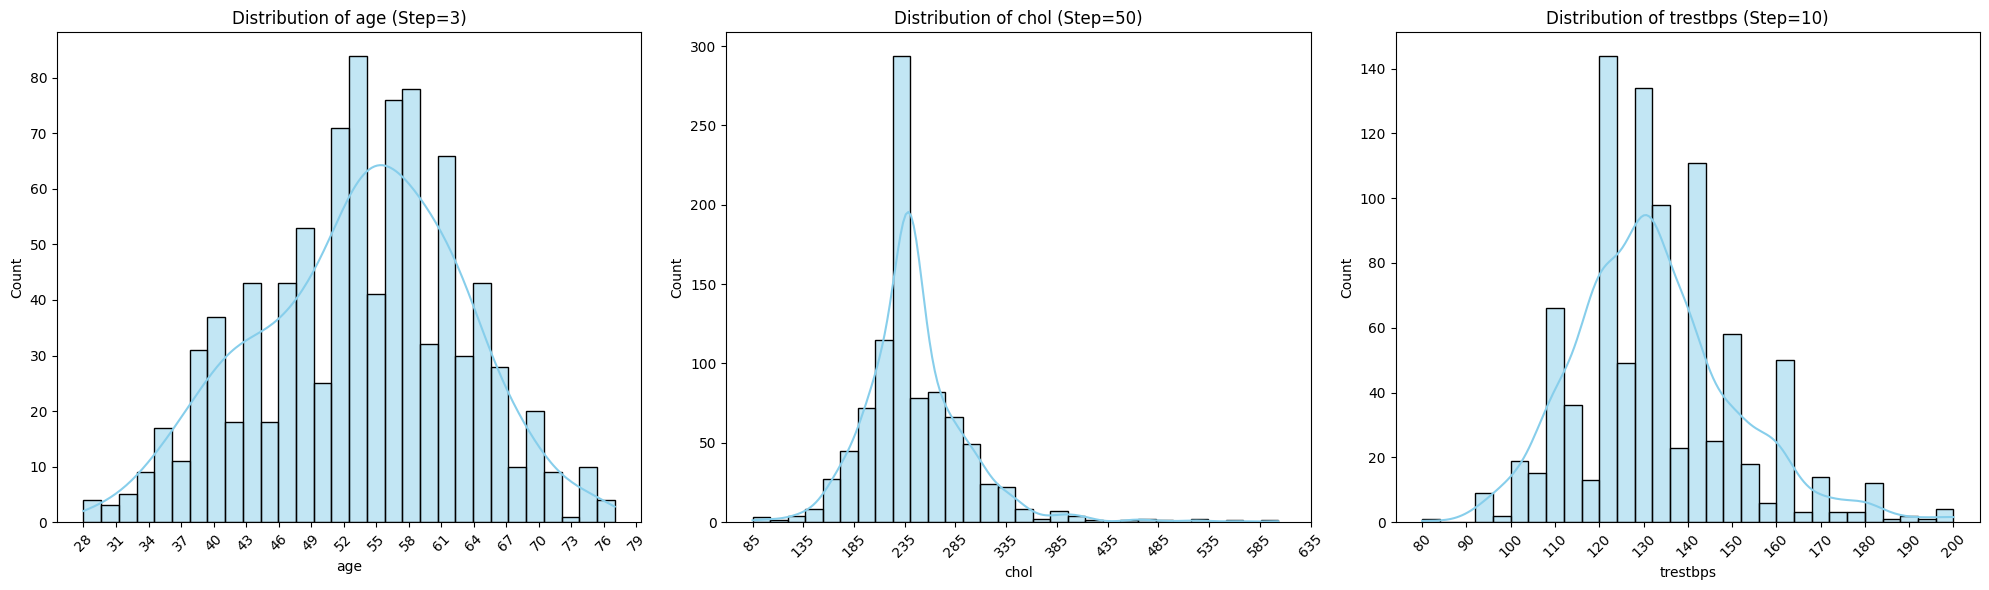

In [ ]:
plt.figure(figsize=(20, 6))

for i, col in enumerate(continuous_features):
    plt.subplot(1, 3, i+1)

    # Vẽ biểu đồ
    sns.histplot(df[col], kde=True, color='skyblue', bins=30)

    # Tính toán giới hạn trục X để chia thước
    start = int(df[col].min())
    end = int(df[col].max())

    # Thiết lập thước chia (xticks)
    # np.arange(bắt đầu, kết thúc + bước nhảy, bước nhảy)
    plt.xticks(np.arange(start, end + steps[col], steps[col]))

    plt.title(f'Distribution of {col} (Step={steps[col]})')
    plt.xticks(rotation=45) # Xoay chữ nếu các con số quá sát nhau

plt.tight_layout()
plt.show()

#### 1. Phân tích Đặc trưng Tuổi (`age`)
*   **Hình dạng phân phối:** Biểu đồ có dạng **hình chuông đối xứng**, rất gần với **phân phối chuẩn (Normal Distribution)**.
*   **Phạm vi dữ liệu:** Tuổi dao động từ khoảng **28 đến 77 tuổi**.
*   **Mật độ tập trung:**
    *   Đỉnh cao nhất nằm ở khoảng **52 - 58 tuổi** (với hơn 80 người ở mỗi cột mốc tuổi này).
    *   Đường KDE mượt mà cho thấy sự chuyển tiếp liên tục, không có sự đứt gãy lớn giữa các nhóm tuổi.
*   **Ý nghĩa:** Bộ dữ liệu tập trung chủ yếu vào đối tượng **trung niên và người cao tuổi** (từ 45 đến 65 tuổi). Đây là nhóm đối tượng có nguy cơ mắc bệnh tim mạch cao nhất trong thực tế, giúp mô hình máy học học được các đặc điểm quan trọng của nhóm nguy cơ.

#### 2. Phân tích Đặc trưng Cholesterol (`chol`)
*   **Hình dạng phân phối:** Phân phối có **độ lệch phải (Positive Skew)** rõ rệt.
*   **Phạm vi dữ liệu:** Dao động rộng từ dưới **100 đến hơn 600 mg/dl**.
*   **Mật độ tập trung:**
    *   Cột cao nhất nằm trong khoảng **200 - 250 mg/dl** (gần 300 người tập trung tại đây).
    *   Phần lớn dữ liệu (đỉnh của đường KDE) nằm quanh mức **240 mg/dl**.
*   **Giá trị ngoại lệ (Outliers):** Xuất hiện một "đuôi" dài về phía bên phải. Có những bệnh nhân có chỉ số cực cao (> 400 mg/dl).
*   **Ý nghĩa y khoa:** Theo tiêu chuẩn, mức Cholesterol > 240 mg/dl được coi là cao. Biểu đồ cho thấy một lượng lớn bệnh nhân trong tập dữ liệu này đang ở ngưỡng **nguy cơ cao hoặc rất cao** về mỡ máu.

#### 3. Phân tích Đặc trưng Huyết áp lúc nghỉ (`trestbps`)
*   **Hình dạng phân phối:** Phân phối có nhiều đỉnh nhỏ (Multimodal) nhưng tập trung chính quanh một vùng, hơi lệch về bên phải.
*   **Phạm vi dữ liệu:** Dao động từ khoảng **90 đến 200 mmHg**.
*   **Mật độ tập trung:**
    *   Có hai đỉnh rõ rệt nhất ở mức **120 mmHg** và **130 mmHg** (mỗi nhóm có khoảng 140 bệnh nhân). Đây là mức huyết áp phổ biến ở người trưởng thành.
    *   Có một nhóm nhỏ bệnh nhân có huyết áp rất cao từ **160 đến 200 mmHg**.
*   **Ý nghĩa y khoa:** Mức 120/80 là bình thường. Từ 130-139 là tiền tăng huyết áp, và trên 140 là tăng huyết áp. Biểu đồ cho thấy tỉ lệ bệnh nhân bị **cao huyết áp** trong tập dữ liệu này là khá lớn.

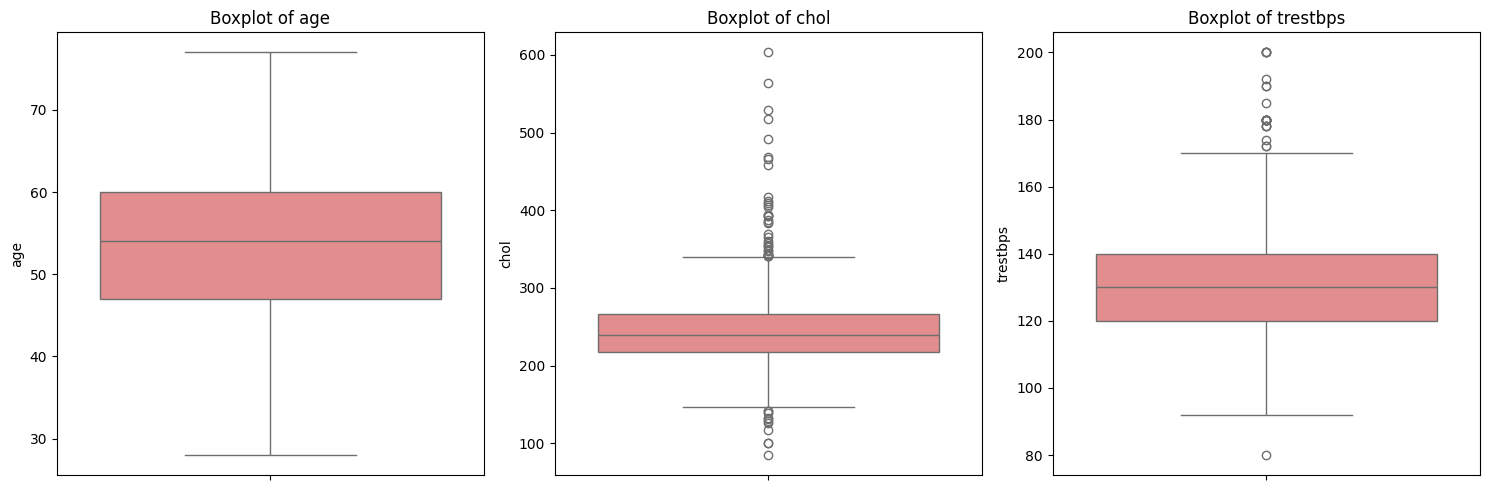

In [ ]:
plt.figure(figsize=(15, 5))

for i, col in enumerate(continuous_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

### Phân tích chi tiết bằng Boxplot
#### 1. Boxplot of ```age``` (Tuổi)
*   **Giá trị trung vị (Median):** Đường vạch ngang nằm giữa hộp ở khoảng **54 tuổi**.
*   **Khoảng tứ phân vị (IQR):** Hộp (chứa 50% lượng bệnh nhân) nằm trong khoảng từ **47 đến 60 tuổi**.
*   **Giá trị ngoại lai (Outliers):** **Không có.**
    *   *Nhận xét:* Dữ liệu tuổi tác rất sạch và phân bố đều. Các "râu" của biểu đồ kéo dài từ khoảng 28 đến 77 tuổi mà không có điểm nào bị tách rời. Điều này khẳng định độ tuổi trung niên là đối tượng nghiên cứu chính.

#### 2. Boxplot of ```chol``` (Cholesterol)
*   **Giá trị trung vị (Median):** Khoảng **240 mg/dl**.
*   **Giá trị ngoại lai (Outliers):** **Rất nhiều và cực kỳ phân tán.**
    *   **Phía trên (High Outliers):** Có một lượng lớn các dấu chấm tròn nằm trên mức **340 mg/dl**, kéo dài lên tới tận **603 mg/dl**.
    *   **Phía dưới (Low Outliers):** Có vài bệnh nhân có mức cholesterol thấp bất thường (dưới 150 mg/dl).
    *   *Nhận xét:* Cholesterol là biến có dữ liệu "nhiễu" nhất. Tuy nhiên, trong y khoa, các giá trị cực cao (> 400 mg/dl) thường là những ca bệnh lý nghiêm trọng. Việc có nhiều ngoại lệ cho thấy chỉ số này có khả năng phân loại bệnh nhân rất cao.

#### 3. Boxplot of ```trestbps``` (Huyết áp lúc nghỉ)
*   **Giá trị trung vị (Median):** Nằm chính xác ở mức **130 mmHg**.
*   **Khoảng tứ phân vị (IQR):** Rất tập trung, 50% dữ liệu chỉ nằm gọn trong khoảng **120 - 140 mmHg**.
*   **Giá trị ngoại lai (Outliers):**
    *   **Phía trên:** Có nhiều điểm ngoại lệ từ **170 đến 200 mmHg**. Đây là các bệnh nhân đang trong tình trạng cao huyết áp cấp độ 2 hoặc 3.
    *   *Nhận xét:* Dữ liệu huyết áp cho thấy xu hướng "nén" lại ở mức 120-140 nhưng lại có những ca cực đoan ở phía cao.

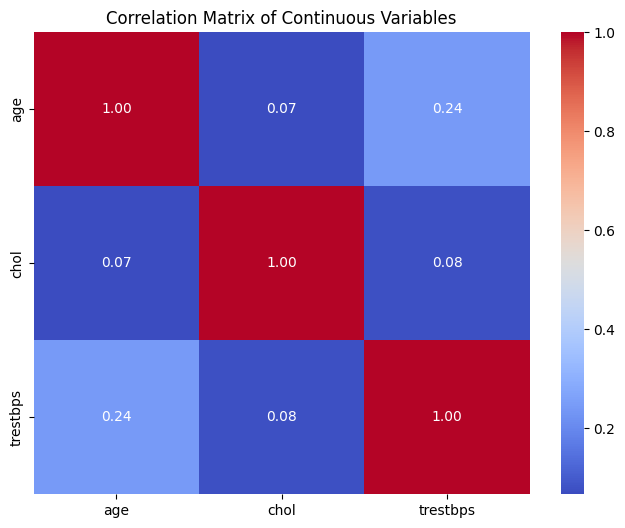

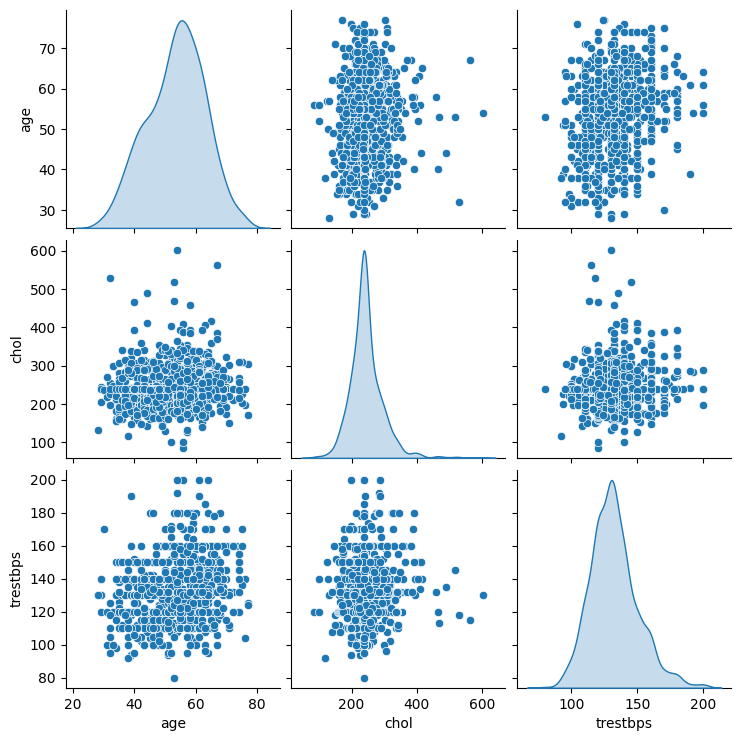

In [ ]:
# Ma trận tương quan
correlation_matrix = df[continuous_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Continuous Variables')
plt.show()

# Biểu đồ tán xạ (Scatter plot) cặp đôi
sns.pairplot(df[continuous_features], diag_kind='kde')
plt.show()


#### 1. Phân tích Ma trận tương quan (Heatmap)
Biểu đồ này thể hiện mối quan hệ tuyến tính giữa các cặp biến số liên tục thông qua hệ số tương quan Pearson ($r$).

*   **Mối quan hệ giữa Tuổi (`age`) và Huyết áp (`trestbps`):** Đạt hệ số **0.24**. Đây là mối tương quan thuận chiều rõ nét nhất trong bộ dữ liệu. Điều này cho thấy xu hướng sinh học tự nhiên: khi tuổi tác tăng lên, huyết áp lúc nghỉ cũng có khuynh hướng tăng theo, mặc dù mức độ tương quan chỉ ở mức yếu đến trung bình.
*   **Mối quan hệ giữa Cholesterol (`chol`) với các biến khác:** Hệ số tương quan giữa Cholesterol với Tuổi và Huyết áp đều rất thấp (lần lượt là **0.07** và **0.08**). Điều này chỉ ra rằng nồng độ Cholesterol là một yếu tố độc lập; một người có huyết áp cao hoặc tuổi cao không nhất thiết phải có chỉ số cholesterol cao và ngược lại.
*   **Đánh giá chung:** Tất cả các hệ số tương quan đều nằm dưới ngưỡng **0.3**. Điều này khẳng định các đặc trưng trong bộ dữ liệu mang tính bổ trợ hơn là trùng lặp. Việc không có hiện tượng đa cộng tuyến (tương quan quá mạnh giữa các biến độc lập) là một điều kiện lý tưởng để xây dựng các mô hình dự báo ổn định.

### 2. Phân tích Biểu đồ cặp (Pairplot)
Biểu đồ này cung cấp cái nhìn đa chiều về phân phối của từng biến (đường chéo) và sự phân tán của các cặp biến (các ô còn lại).

#### **A. Phân phối của từng đặc trưng (Biểu đồ KDE trên đường chéo):**
*   **Tuổi (`age`):** Có hình dạng gần giống phân phối chuẩn, tập trung mạnh nhất ở độ tuổi từ **50 đến 60**. Dữ liệu bao phủ rộng từ 30 đến gần 80 tuổi, cho thấy tính đại diện cao cho nhóm đối tượng trung niên.
*   **Cholesterol (`chol`):** Phân phối bị lệch phải (Positive Skew) với một đỉnh nhọn quanh mức **240 mg/dl**. Đáng chú ý là "đuôi" dữ liệu kéo dài về phía bên phải với nhiều giá trị ngoại lai vượt mức **400 - 600 mg/dl**, phản ánh nhóm bệnh nhân có tình trạng rối loạn lipid máu nghiêm trọng.
*   **Huyết áp (`trestbps`):** Phân phối tập trung vào dải giá trị từ **120 đến 140 mmHg**. Đường cong mật độ rất mượt mà và nằm hoàn toàn trong dải giá trị y khoa thực tế (từ khoảng 90 đến 200 mmHg), cho thấy dữ liệu có độ tin cậy cao.

#### **B. Mối quan hệ tương quan (Biểu đồ phân tán - Scatter plots):**
*   **Sự phân tán dữ liệu:** Các điểm dữ liệu tạo thành các "đám mây" phân tán rộng, không tập trung thành đường thẳng rõ rệt. Điều này minh chứng cho việc các yếu tố nguy cơ tim mạch tác động lên nhau theo những cách phức tạp và phi tuyến tính.
*   **Đặc điểm các biến:**
    *   Ở cặp `age` và `trestbps`, mật độ các điểm dữ liệu dày hơn ở góc trên bên phải, củng cố cho nhận định về mối tương quan thuận giữa tuổi tác và huyết áp.
    *   Các điểm ngoại lệ của `chol` xuất hiện rải rác ở mọi độ tuổi, cho thấy nguy cơ cholesterol cao có thể xảy ra ở cả bệnh nhân trẻ tuổi lẫn người già.


---
---

## 2.2. So sánh ```chol```, ```thalach``` giữa nhóm bệnh và không bệnh bằng Boxplot

Vẽ biểu đồ Boxplot.

Median nồng độ Cholesterol (chol) theo target:
target
0    239.5
1    239.5
Name: chol, dtype: float64 

Median nhịp tim tối đa (thalach) theo target:
target
0    150.0
1    130.0
Name: thalach, dtype: float64 



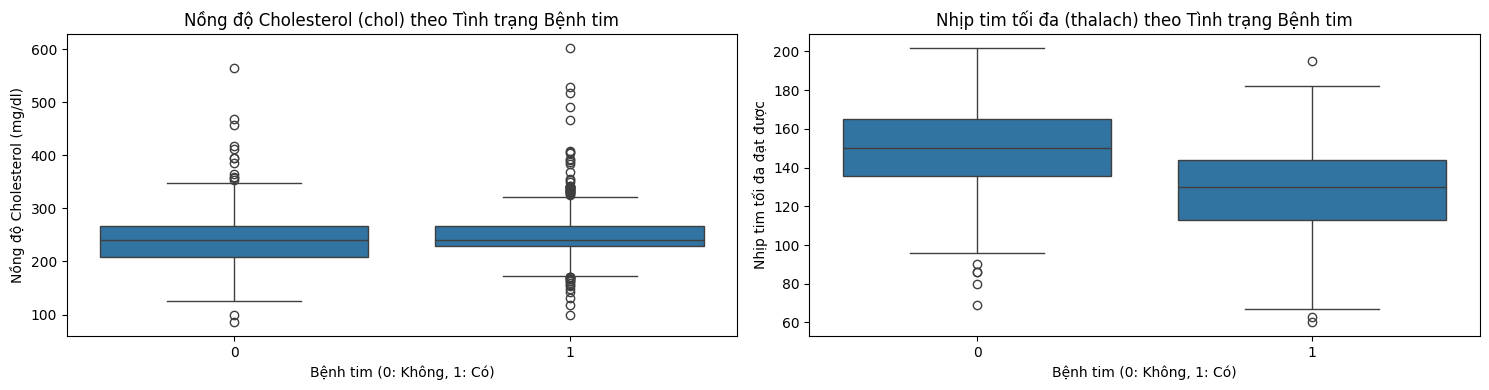

In [ ]:
df['target'] = (df['num'] > 0).astype(int)

# In median của chol và thalach theo từng nhóm bệnh tim
print("Median nồng độ Cholesterol (chol) theo target:")
print(df.groupby('target')['chol'].median(), "\n")

print("Median nhịp tim tối đa (thalach) theo target:")
print(df.groupby('target')['thalach'].median(), "\n")

plt.figure(figsize=(15, 4))

# Boxplot for chol vs target
plt.subplot(1, 2, 1)
sns.boxplot(x='target', y='chol', data=df)
plt.title('Nồng độ Cholesterol (chol) theo Tình trạng Bệnh tim')
plt.xlabel('Bệnh tim (0: Không, 1: Có)')
plt.ylabel('Nồng độ Cholesterol (mg/dl)')

# Boxplot for thalach vs target
plt.subplot(1, 2, 2)
sns.boxplot(x='target', y='thalach', data=df)
plt.title('Nhịp tim tối đa (thalach) theo Tình trạng Bệnh tim')
plt.xlabel('Bệnh tim (0: Không, 1: Có)')
plt.ylabel('Nhịp tim tối đa đạt được')

plt.tight_layout()
plt.show()


###So sánh Chol, thalach giữa hai nhóm bệnh và không:

Nồng độ Cholesterol theo tình trạng bệnh tim:  
  - Median: Giá trị median của cả hai nhóm đều là 239,5 mg/dl, ta thấy được mức độ cholesterol trung bình không có sự khác biệt.  
  - Mức độc phân tán và ngoại lai: Tuy Median của 2 nhóm là bằng nhau những theo biểu đồ thấy được sự khác biệt về độ phân tán (IQR) và số lượng các giá trị ngoại lai. Nhóm mắc bệnh (target = 1) có phân bố rộng hơn, nhiều ngoại lai hơn nên thấy được sự biến động lớn, các trường hợp cholesterol bất thường.
  - Nhận xét : Mức ```Cholesterol``` không có tính phân biệt bởi vì giá trị trung bình bằng nhau.

Nhịp tim tối đa đạt được ```thalach``` theo tình trạng bệnh tim:
  - Median: Nhóm không mắc bệnh (target = 0) có median `thalach` là 150.0 bpm, trong khi nhóm mắc bệnh (target = 1) có median `thalach` là 130.0 bpm. Điều này cho thấy những người không mắc bệnh tim có xu hướng đạt được nhịp tim tối đa cao hơn đáng kể so với những người mắc bệnh tim.
  - Phân tán và ngoại lai: Có sự khác về độ phân tán và ngoại lai giữa hai nhóm, với nhóm không bệnh thường có phân bố tập trung hơn hoặc ngoại lai ở mức cao hơn còn nhóm bị bện có ngoại lai ở cả hai phía do tình trạng bệnh lý đa dạng.
  - Nhận xét : Nhịp tim tối đa ở nhóm bị bệnh tim thấp hơn nên có thể sử dụng thuộc tính này đẽ dự đoán tính trạng bệnh của các bệnh nhân,
  

---
---

## 2.3. Phân tích tỉ lệ mắc bệnh theo ```sex```, ```cp``` bằng Barplot

Vẽ biểu đồ Barplot.

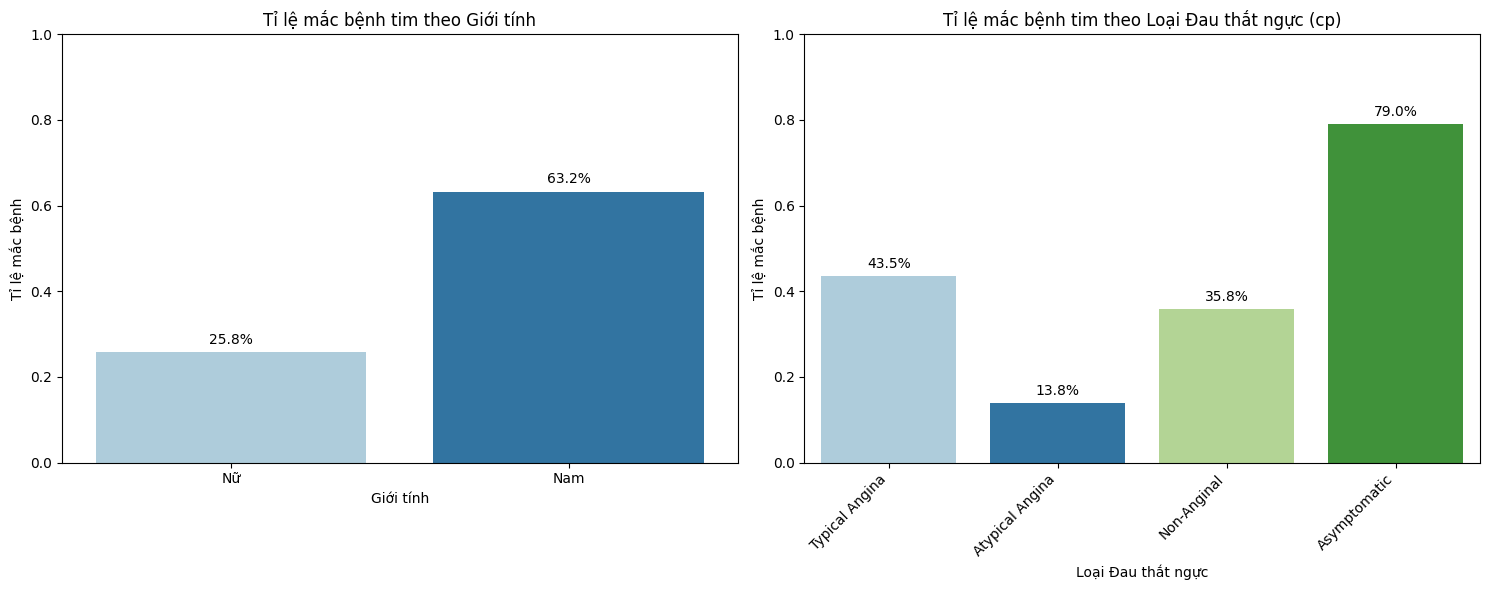

In [ ]:
# Calculate disease rate by sex
disease_by_sex = df.groupby('sex')['target'].mean().reset_index()
disease_by_sex['sex_label'] = disease_by_sex['sex'].map({0: 'Nữ', 1: 'Nam'})

# Calculate disease rate by cp
disease_by_cp = df.groupby('cp')['target'].mean().reset_index()
cp_labels = {
    1: 'Typical Angina',
    2: 'Atypical Angina',
    3: 'Non-Anginal',
    4: 'Asymptomatic'
}
disease_by_cp['cp_label'] = disease_by_cp['cp'].map(cp_labels)

plt.figure(figsize=(15, 6))

# Barplot for disease rate by sex
plt.subplot(1, 2, 1)
ax1 = sns.barplot(x='sex_label', y='target', data=disease_by_sex, palette='Paired')
plt.title('Tỉ lệ mắc bệnh tim theo Giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Tỉ lệ mắc bệnh')
plt.ylim(0, 1)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height()*100:.1f}%',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# Barplot for disease rate by cp
plt.subplot(1, 2, 2)
ax2 = sns.barplot(x='cp_label', y='target', data=disease_by_cp, palette='Paired')
plt.title('Tỉ lệ mắc bệnh tim theo Loại Đau thắt ngực (cp)')
plt.xlabel('Loại Đau thắt ngực')
plt.ylabel('Tỉ lệ mắc bệnh')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for p in ax2.patches:
    ax2.annotate(f'{p.get_height()*100:.1f}%',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

###Phân tích biểu đồ Barplot:
Tỉ lệ mắc bệnh tim theo Giới tính:
  - Biểu đồ bên trái thể hiện rõ ràng sự khác biệt về tỉ lệ mắc bệnh tim giữa hai giới.
  - ```Nữ (0)```: Tỉ lệ mắc bệnh tim là khoảng 25.8%.
  - ```Nam (1)```: Tỉ lệ mắc bệnh tim cao hơn đáng kể, ở mức khoảng 63.2%.
  - ```Nhận xét```: Giới tính Nam có nguy cơ mắc bệnh tim cao hơn đáng kể so với giới tính Nữ trong tập dữ liệu này. Đây là một yếu tố quan trọng có thể được sử dụng trong các mô hình dự đoán.

Tỉ lệ mắc bệnh tim theo Loại Đau thắt ngực (cp):
  - Biểu đồ bên phải trình bày tỉ lệ mắc bệnh tim ứng với từng loại đau thắt ngực (chest pain type).
  - ```Asymptomatic (cp = 4)```: Loại đau thắt ngực này, mặc dù không có triệu chứng rõ ràng, lại có tỉ lệ mắc bệnh tim cao nhất, lên đến khoảng 79.0%. Có khả năng bỏ sót trong chuẩn đoán dẫn đến việc bệnh phát triển từ từ.
  - ```Typical Angina (cp = 1)```: Tỉ lệ mắc bệnh tim ở mức trung bình cao hơn, khoảng 43.5%.
  - ```Non-Anginal (cp = 3)```: Tỉ lệ mắc bệnh tim ở mức tương đương với Typical Angina, khoảng 35.8%.
  - ```Atypical Angina (cp = 2)```: Loại đau thắt ngực này cho thấy tỉ lệ mắc bệnh tim thấp nhất, chỉ khoảng 13.8%.
  - ```Nhận xét```: Ta thấy rằng đau thắt ngực 'Asymptomatic' (không triệu chứng) lại có tỷ lệ mắc bệnh cực kì cao . Ngược lại, những người có đau thắt ngực 'Atypical Angina' có tỉ lệ mắc bệnh tim thấp nhất. Loại đau thắt ngược là yếu tố quan trọng để phân loại mực độ rủi ro.

---
---

## 2.4. Kiểm tra tương quan giữa các biến số bằng Correlation Heatmap

Vẽ biểu đồ Correlation Heatmap.

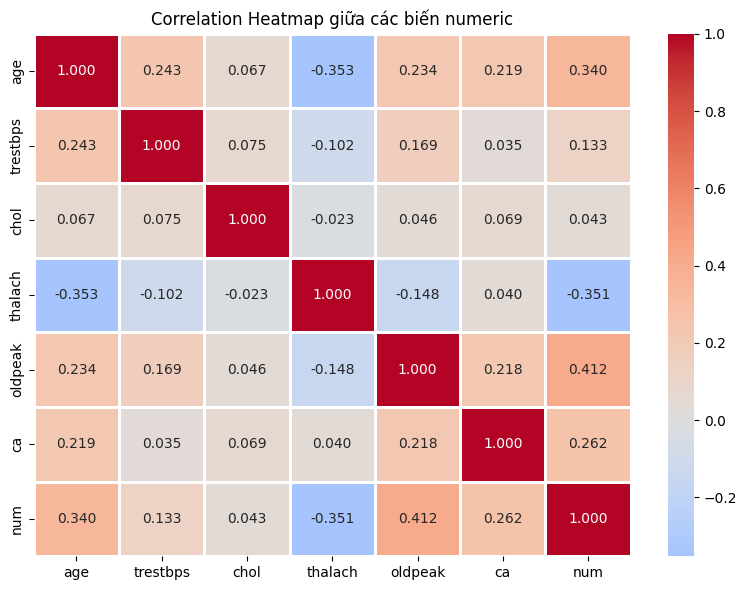

In [ ]:
# Chọn các cột numeric có ý nghĩa
# Không lấy cột id
num_cols = ['age', 'trestbps', 'chol','thalach', 'oldpeak', 'ca', 'num']

# Tính hệ số tương quan Pearson của Correlation Matrix
corr_matrix = df[num_cols].corr(method='pearson')

# Vẽ heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    linewidths=1,
)
plt.title("Correlation Heatmap giữa các biến numeric")
plt.tight_layout()
plt.show()


### Nhận xét về biểu đồ và các mối tương quan:

- Không có cặp biến nào có mối tương quan mạnh (giá trị tuyệt đối trong khoảng 0.9 đến 1), thậm chí không có cặp nào có hệ số tương quan vượt quá 0.5. Điều này cho thấy các biến trong bộ dữ liệu không bị đa cộng tuyến nghiêm trọng, nhưng cũng đồng nghĩa rằng không có mối liên hệ tuyến tính mạnh giữa các biến và biến num không quá áp đảo.

- Các mối quan hệ tương quan dương đáng chú ý:
    - ```oldpeak``` và ```num```: Hệ số tương quan là ~ 0.412, là hệ số dương lớn nhất trong ma trận. Ta thấy 2 biến này có mối tương quan dương vừa phải. Điều này cho thấy rằng khi giá trị ```oldpeak``` (độ lệch ST) tăng, thì khả năng mắc bệnh tim (```num```) cũng có xu hướng tăng.
    - ```age``` và ```num```: Hệ số tương quan là ~ 0.34, cũng là một mối tương quan dương vừa phải. Ta thấy rằng khi tuổi tác càng cao thì khả năng mắc bệnh tim cũng tăng.
    - Các cặp biến như ```num``` và ```ca``` (hệ số ~ 0.262), ```ca``` và ```age``` (hệ số ~ 0.219), ```ca``` và ```oldpeak``` (hệ số ~ 0.218), ```oldpeak``` và ```age``` (hệ số ~0.212), ```oldpeak``` và ```trestbps``` (hệ số ~0.16), ```trestbps``` và ```age``` (hệ số ~ 0.235) cũng có mối tương quan dương yếu với nhau.
    - ```chol``` gần như không gây ra ảnh hưởng nào đáng kể đến các biến khác trong bộ dữ liệu, khi toàn bộ các hệ số đều < 0.1.

- Các mối quan hệ tương quan âm đáng chú ý:
    - ```thalach``` và ```age```: Hệ số tương quan là ~ -0.353, là hệ số âm lớn nhất trong ma trận. Ta có thể nhận xét rằng khi tuổi tác tăng thì nhịp tim tối đa (```thalach```) có xu hướng giảm.
    - ```thalach``` và ```num```: Hệ số tương quan là ~ -0.351, cũng là một mối tương quan âm vừa phải. Cặp biến này có mối tương quan âm vừa phải. Đièu này cho thấy nhịp tim tối đa càng thấp thì các nguy cơ mắc bệnh tim càng hiện hữu.

- Các cặp quan hệ còn lại có hệ số rất nhỏ, gần như không tạo ra thêm mối tương quan tuyến tính nào đáng chú ý.

Hậu suy:

- Biến ```num``` là ordinal, do đó hệ số Pearson có thể không phản ánh đầy đủ mối quan hệ giữa num và các biến khác.
- Các hệ số tương quan đều không quá lớn, do đó không nên kết luận nhân-quả chỉ dựa trên ma trận tương quan này.
- Cần phải sử dụng các phương pháp phân tích khác (như kiểm định, hồi quy logistic, v.v.) để hiểu rõ hơn
về ảnh hưởng của các biến này đến num.

---
---

## 2.5. Quan sát mối quan hệ giữa các biến liên tục quan trọng bằng Pairplot / Scatter Matrix

Vẽ biểu đồ Pairplot / Scatter Matrix.

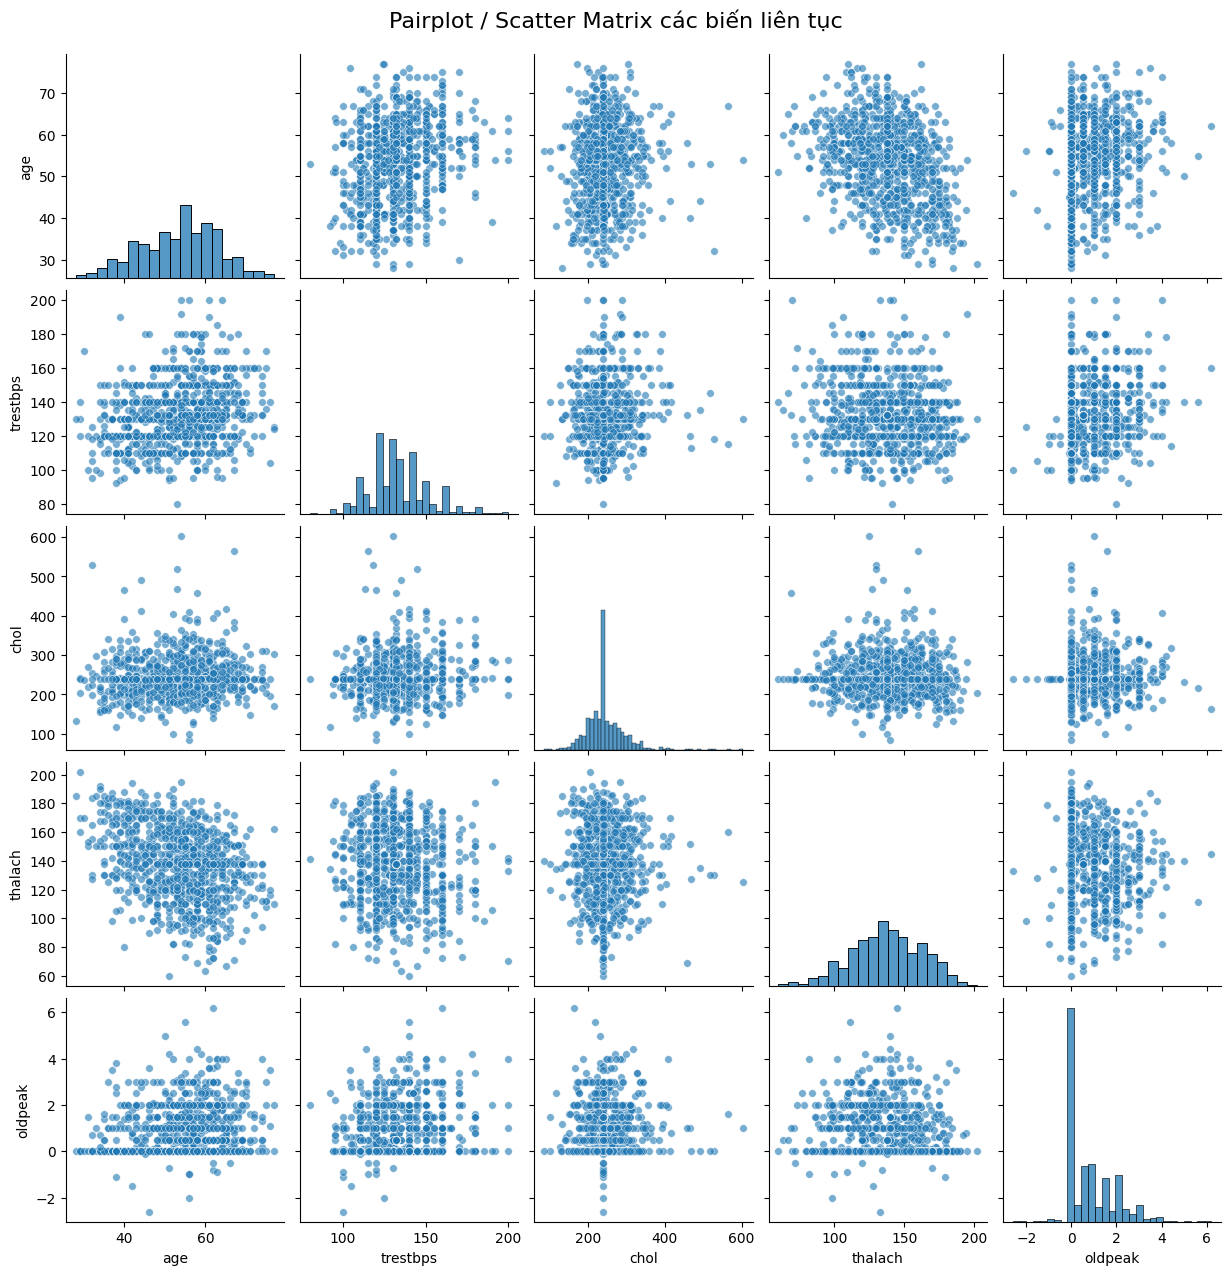

In [ ]:
# Lọc ra các biến liên tục
continuous_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
# Vẽ pairplot
sns.pairplot(
    df[continuous_features],
    plot_kws={
        "alpha": 0.6,
        "s": 30
    }
)
# Điều chỉnh tiêu đề cho biểu đồ
plt.suptitle(
    "Pairplot / Scatter Matrix các biến liên tục",
    fontsize=16,
    y=1.02
)

plt.show()

### Mô tả sau khi quan sát các biến liên tục quan trọng bằng biểu đồ
Phân phối:
- ```age```: phân phối gần chuẩn, ít outliers và khá ổn định.
- ```trestbps```: phân phối có sự lệch phải nhẹ, có xuất hiện 1 vài outliers cả thấp và cao.
- ```chol```: phân phối có sự lệch phải rõ rệt, có nhiều giá trị cao bất thường, không tuân theo phân phối chuẩn.
- ```thalach```: phân phối tương đối đối xứng gần chuẩn, biến này vừa có tính liên tục vừa có tính ổn định.
- ```oldpeak```: phân phối lệch phải rất mạnh, có nhiều giá trị tập trung gần giá trị 0 và có đuôi dài chứng tỏ có outliers khá rõ rệt.

Mối quan hệ giữa các biến:
- ```age``` và  ```thalach```: có một sự tương quan âm khá rõ ràng, có xu hướng đối nghịch nhau giữa 2 biến.
- ```age``` và  ```trestbps```: có sự tương quan, trong đó xu hướng tăng nhẹ.
- ```chol``` với các biến khác: dữ liệu có sự phân tán mạnh, không có sự tương quan tuyến tính rõ rệt.
- ```oldpeak``` với các biển khác: không tuyến tính có sự phân tán lớn, nhiều điểm tập trung ở giá trị thấp.
- ```chol``` và  ```trestbps```: hai biến có sự độc lập với nhau vì không có xu hướng rõ rệt.

